## 激活函数

激活函数（Activation Function）是神经网络中的一个重要组成部分，它决定了神经元的输出。实际上是对神经元的加权和进行非线性变换，从而引入非线性因素，使得神经网络能够学习和表示复杂的函数关系。

In [44]:
import numpy as np


# 阶跃函数
def step_function(x: np.ndarray) -> np.ndarray:
    y = x > 0
    return y.astype('int')


step_function(np.array([-1.0, 1.0, 2.0]))  # array([0, 1, 1])

array([0, 1, 1])

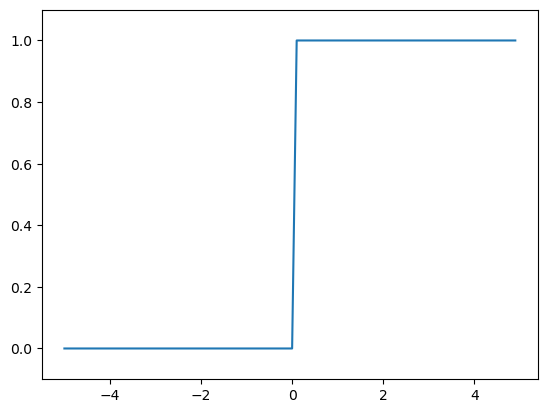

In [45]:
# 阶跃函数图像
import numpy as np
import matplotlib.pylab as plt

x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)  # 指定y轴的范围
plt.show()

In [46]:
# sigmoid 函数实现

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


sigmoid(np.array([-1.0, 1.0, 2.0]))  # array([0.26894142, 0.73105858, 0.88079708])

array([0.26894142, 0.73105858, 0.88079708])

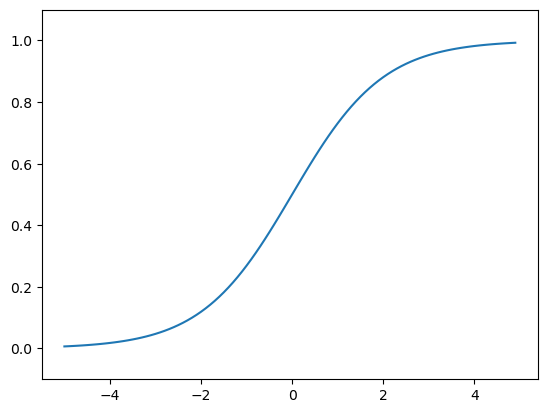

In [47]:
# sigmoid 函数图像
import numpy as np
import matplotlib.pylab as plt

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)  # 指定y轴的范围
plt.show()

sigmoid 函数和阶跃函数类似，但它是一个平滑的曲线，没有阶跃函数的突变现象。这种平滑性使得 sigmoid 函数在训练神经网络时更容易进行梯度下降优化。

它们在输入信号较大或较小时，输出趋近于 0 或 1，这可能导致梯度消失问题，从而影响深层神经网络的训练效果。

## 非线性函数

神经网络的激活函数必须使用非线性函数，否则无论网络有多少层，其整体仍然相当于一个线性变换，无法解决复杂的非线性问题。使用线性函数的话，加深网络层数并不会增加模型的表达能力。

## ReLU 函数

ReLU（Rectified Linear Unit）函数是一种常用的激活函数，定义为 f(x) = max(0, x)。它在输入大于 0 时输出输入本身，在输入小于等于 0 时输出 0。ReLU 函数具有计算简单、收敛速度快等优点，广泛应用于深度神经网络中。

In [48]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)

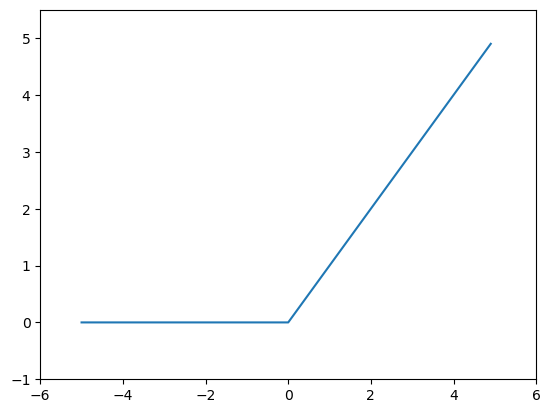

In [49]:
# sigmod 函数图像
import numpy as np
import matplotlib.pylab as plt

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.xlim(-6, 6)
plt.ylim(-1, 5.5)  # 指定y轴的范围
plt.show()

## 多维数组运算

In [50]:
A = np.array([1, 2, 3, 4])

# 一维数组
print(np.ndim(A))  # 1

print(A.shape)  # (4,)

print(A.shape[0])  # 4

1
(4,)
4


In [51]:
B = np.array([[1, 2], [3, 4], [5, 6]])

print(B)

print(np.ndim(B))  # 2

# 第一个维度有 3 个元素，第二个维度有 2 个元素，即 3行2列
print(B.shape)  # (3, 2)

[[1 2]
 [3 4]
 [5 6]]
2
(3, 2)


## 神经网络的前向处理

![三层神经网络](assset/pictures/3.1-3层神经网络.png)

In [ ]:
def init_network():
    network = {}

    # 输入层到隐藏层的权重和偏置
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])

    # 第一层隐藏层到第二层隐藏层的权重和偏置
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])

    # 第二层隐藏层到输出层的权重和偏置
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])

    return network


def forward(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']  # 获取各层的权重矩阵
    b1, b2, b3 = network['b1'], network['b2'], network['b3']  # 获取各层的偏置
    a1 = np.dot(x, W1) + b1  # 第一层的加权输入
    z1 = sigmoid(a1)  # 第一层的激活输出
    a2 = np.dot(z1, W2) + b2  # 第二层的加权输入
    z2 = sigmoid(a2)  # 第二层的激活输出
    a3 = np.dot(z2, W3) + b3  # 输出层的加权输入
    y = identity_function(a3)  # 输出层的激活输出
    return y


identity_function = lambda x: x

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

输出层所用的激活函数，要根据求解问题的性质决定。一般地，回归问题可以使用恒等函数，二元分类问题可以使用sigmoid函数，多元分类问题可以使用softmax函数。

## 输出层设计

机器学习的问题大致可以分为分类问题和回归问题。分类问题是数据属于哪一个类别的问题。比如，区分图像中的人是男性还是女性的问题就是分类问题。而回归问题是根据某个输入预测一个（连续的）数值的问题。比如，根据一个人的图像预测这个人的体重的问题就是回归问题（类似“57.4kg”这样的预测）。

### 恒等函数和 softmax 函数
恒等函数会将输入按原样输出，对于输入的信息，不加以任何改动地直接输出。

分类问题中使用的 softmax 函数可以用以下的式来表示：

$$y_k = \frac{\exp(a_k)}{\displaystyle\sum_{i=1}^{n} \exp(a_i)}$$

其中：
- $y_k$ 是第 $k$ 个输出
- $a_k$ 是第 $k$ 个输入
- $n$ 是输出个数
- 分母是所有输入的指数和

In [ ]:
def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

def softmax(a: np.ndarray) -> np.ndarray:
    c = np.max(a)  # 防止溢出
    exp_a = np.exp(a - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

## 如何选择激活函数

1) 隐藏层
   - 首选 ReLU，如果效果不好可尝试Leaky ReLU等。
   - Sigmoid在隐藏层易导致梯度消失，应尽量避免。
   - Tanh的输出均值为0，对中心化数据更友好，但仍可能引发梯度消失，仅适用于浅层网络。

2) 输出层
    - 二分类选择 Sigmoid。
    - 多分类选择 Softmax。
    - 回归默认选择 Identity。